# Выбор локации для скважины. Обучение моделей и анализ рисков.

Добывающей компании «ГлавРосГосНефть» нужно решить, где бурить новую скважину. Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

По условиям задачи для обучения модели подходит только линейная регрессия.

**Основные особенности после обзора и исследования данных:**
* Данные о втором регионе (geo_data_1) имеют критические аномалии: целевой признак представлен лишь 12-ю значениями на 100 тысяч скважен, и идеально линейно зависим от признака f2, который также распределён лишь в 6 групп значений (тоже аномалия) - это позволяет полностью предсказать объём от f2. Обучать модель на таких данных бессмысленно. В остальных данных проблем нет;
* В первом регионе нам удалость найти и разделить 2 группы значений в данных, это поможет улучшить модель сделав предсказания точнее т.к. распределение объёма по этим группам разное. Средний запас объёма в скважинах равен 92.5;
* Третий регион содежит самый большой средний объём запасов в скважинах: 95 - это делает его потенциально самым прибыльным. Признаки объясняют целевой хуже чем в первом регионе, хотя есть предпосылки для развития: узкий диапазон значений f0 и f1 представляют лишь минимальные объёмы запасов, это позволит отделить самые убыточные скважены;

## Содержание
* [Обучение моделей](#intro)
* * [Подготовка данных](#prep)
  * [Первый регион](#first)
  * [Второй регион](#sec)
  * [Третий регион](#third)
* [Подготовка к расчёту прибыли](#prep2)
* [Рассчёт прибыли и рисков при помощи bootstrap](#calc)
* [Вывод и рекомендации](#end)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.random import RandomState
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error, r2_score

RANDOM_STATE = 228
TEST_SIZE = 0.25

Загрузим данные о скважинах в трёх регионах

In [2]:
names = ['geo_data_0_prep', 'geo_data_1', 'geo_data_2']

df0, df1, df2 = [pd.read_csv(f'../data/{name}.csv') for name in names]

## Обучение и проверка модели <a id="intro"></a>

### Подготовка <a id="prep"></a>

Напишем функцию которая будет разделять данные на тренировочную и валидационную выборки.

In [3]:
def split(df, target='product', ids='id'):
    
    df = df.drop(columns=ids)
    X = df.drop(columns=target)
    y = df[target]
    
    return train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

Для оценки качества модели будем использовать корень среднеквадратичной ошибки и R2 (коэффициент детерминации). Также построим графики для анализа остатков.

In [4]:
def metrics(y_test, pred):
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    residuals = y_test - pred

    sns.set_style('whitegrid')
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    bins = np.histogram_bin_edges(residuals, bins='doane')
    
    axs[0].hist(residuals, bins=bins)
    axs[0].set(title='Гистограмма остатков', xlabel='Остатки')
    axs[1].scatter(pred, residuals, alpha=0.2)
    axs[1].set(title='Анализ дисперсии', xlabel='Предсказания', ylabel='Остатки')
    
    plt.tight_layout()
    plt.show()

    print(f'RMSE = {rmse:.3f}\nR2 = {r2:.3f}\nbias = {residuals.mean():.3f}')
    print('')
    print(f'Средний запас предсказанного объёма = {pred.mean():.3f}')
    print(f'Средний запас фактического объёма = {y_test.mean():.3f}')

In [5]:
def coefs(pipeline, X_columns):
    coefficients = pipeline.named_steps['model'].coef_.flatten()
    feature_importance = pd.DataFrame({'Признак': X_columns.to_list(), 'Коэффициент': coefficients})

    return feature_importance

В наших данных только непрерывные числовые признаки, значит этап подготовки будет состоять из масштабирования. Для модели с бинарным признаком сделаем отдельный пайплайн

In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

### Первый регион <a id="first"></a>

In [7]:
#разделение на выборки
X_train, X_valid, y_train, y_valid = split(df0.drop(columns=['cluster']))

In [8]:
#масштабирование и обучение модели
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [9]:
#получение прогнозов на валидационной выборке
y_pred = pipeline.predict(X_valid)

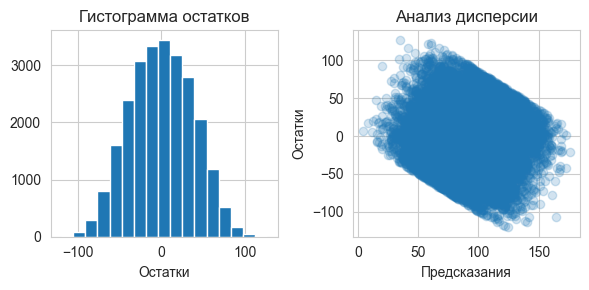

RMSE = 37.715
R2 = 0.277
bias = -0.195

Средний запас предсказанного объёма = 92.575
Средний запас фактического объёма = 92.381


In [10]:
metrics(y_valid, y_pred);

Средняя ошибка 37.7 тысяч баррелей, коэффициент детерминации (R2) достаточно низкий: 0.277, значит модель плохо "понимает" данные, это логично ведь при анализе признаки показывали слабую линейную связь с целевым. Среднее значение предсказанного запаса почти совпадает с действительным.

Анализ остатков: гистограмма симметрична относительно нуля, это хорошо - модель одинаково часто делает завышенные и заниженные прогнозы, никаких смещений нет, среднее значение остатков также близко к нулю. На графике анализа дисперссии видно, что ошибки имеют одинаковую дисперсию на всём графике, хоть и видно снижение средней ошибки по мере увеличения значения объёма. 

Проверим коэффициенты

In [11]:
coefs(pipeline, X_train.columns)

,Признак,Коэффициент
0,f0,3.299342
1,f1,-7.091654
2,f2,21.424933


In [12]:
y_geo0 = y_valid.reset_index(drop=True)
preds0 = pd.Series(y_pred, index=y_geo0.index)

Ожидаемо f2 вносит наибольший вклад в предсказание, остальные учитываются меньше.

**Добавим наш новый бинарный признак** и обучим модель вмемсте с ним.

In [13]:
num_cols = ['f0', 'f1', 'f2']
binar_cols = ['cluster']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('bin', 'passthrough', binar_cols)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [14]:
X_train, X_valid, y_train, y_valid = split(df0)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_valid)

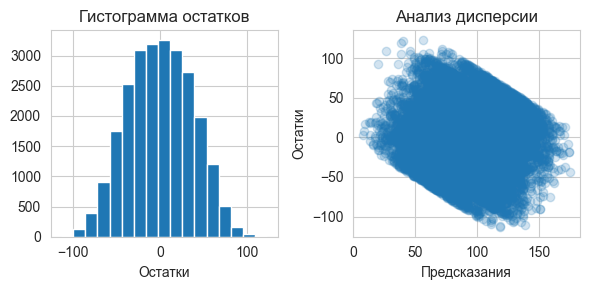

RMSE = 37.151
R2 = 0.298
bias = -0.089

Средний запас предсказанного объёма = 92.470
Средний запас фактического объёма = 92.381


In [15]:
metrics(y_valid, y_pred);

С новым признаком нам удалось снизить ошибку на 0.5 единицы, и увеличить R2 до 0.298 - предсказательная способность модели в этом регионе увеличилась. Анализ остатков также показывает улучшение: среднее остатков стало ещё ближе к нулю, средний прогнозируемый запас точнее к истинному.

In [16]:
coefs(pipeline, X_train.columns)

,Признак,Коэффициент
0,f0,0.015717
1,f1,0.096035
2,f2,21.464340
3,cluster,-22.489341


Новый признак имеет такую же значимость как и f2.

In [17]:
y_geo0_2 = y_valid.reset_index(drop=True)
preds0_2 = pd.Series(y_pred, index=y_geo0_2.index)

### Второй регион <a id="sec"></a>

In [18]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [19]:
X_train, X_valid, y_train, y_valid = split(df1)

In [20]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [21]:
y_pred = pipeline.predict(X_valid)

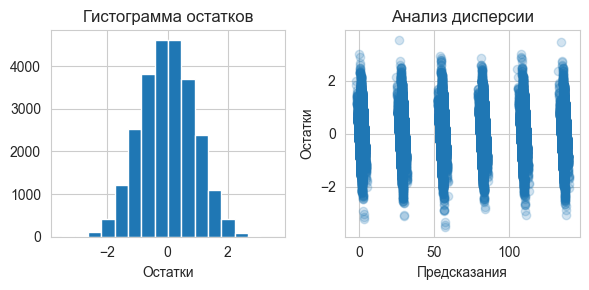

RMSE = 0.889
R2 = 1.000
bias = -0.004

Средний запас предсказанного объёма = 68.706
Средний запас фактического объёма = 68.703


In [22]:
metrics(y_valid, y_pred)

Из-за аномалий в данных и полной линейной зависимости от f2, предсказания модели практически идеальные. Метрика 0.9 - модель делает минимальные ошибки, R2 показывает максимальное значение 1. Использовать такую модель нельзя.

In [23]:
y_geo1 = y_valid.reset_index(drop=True)
preds1 = pd.Series(y_pred, index=y_geo1.index)

### Третий регион <a id="third"></a>

В третьем регионе с целевым признаком связан только признак f2, проверим что покажет модель на этих данных, затем проведём преобразования с признаками и посмотрить есть ли улучшения.

In [24]:
X_train, X_valid, y_train, y_valid = split(df2)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_valid)

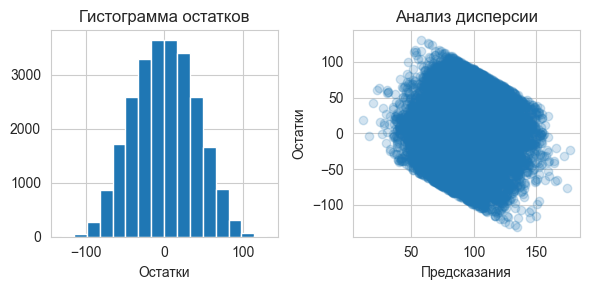

RMSE = 39.938
R2 = 0.196
bias = -0.115

Средний запас предсказанного объёма = 94.971
Средний запас фактического объёма = 94.856


In [25]:
metrics(y_valid, y_pred)

Показатели модели хуже, относительно первого региона: средняя ошибка выше, R2 меньше. Но предсказания объёма в регионе выше.

In [26]:
y_geo2 = y_valid.reset_index(drop=True)
preds2 = pd.Series(y_pred, index=y_geo2.index)

In [27]:
#после переборов вариантов эти признаки показали лучший результат
df2['f0'] = np.log1p(df2['f0']**2)
df2['f1'] = np.log1p(df2['f1']**2)

In [28]:
X_train, X_valid, y_train, y_valid = split(df2)
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_valid)

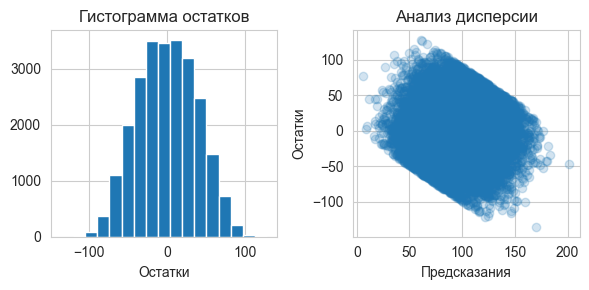

RMSE = 38.275
R2 = 0.261
bias = -0.043

Средний запас предсказанного объёма = 94.899
Средний запас фактического объёма = 94.856


In [29]:
metrics(y_valid, y_pred)

После преобразования признаков f0 и f1 нам удалось добиться более качественного результата: Ошибка снизилась на 1.6 пункта, R2 увеличился. Самое важное, что средний запас прогнозируемого объёма очень близок к реальным, учитывая то, что в этом регионе больше запасов чем в первом.

In [30]:
coefs(pipeline, X_train.columns)

,Признак,Коэффициент
0,f0,8.296882
1,f1,8.338148
2,f2,20.048142


f2 также является наиболее важным признаком, но и остальные признаки теперь тоже важны для прогноза.

In [31]:
y_geo2_2 = y_valid.reset_index(drop=True)
preds2_2 = pd.Series(y_pred, index=y_geo2_2.index)

**Промежуточный вывод**

Мы обучили модели для каждого региона, из-за слабой связи с признаками качество моделей получилось средним, но
* Нам удалось развить найденую закономерность в данных первого региона, из-за чего мы смогли добавить новый бинарный признак который улучшил качество модели снизив среднюю ошибку на 0.5 пунктов: 37.1 тыс. баррелей и увеличил понимание данных это позволилось точнее делать прогноз;
* Для Третьего региона удалось улучшить признаки и уменьшить среднюю ошибку на 1.6 пунктов: 38.2 тысяч баррелей, не смотря на то что модель для третьего региона оказалась немного хуже, этот регион обладает наибольшим запасом объемов (на 2.3 тысячи больше первого) что может окупить ошибку и сделать регион наиболее прибыльным;

Оба региона также показали показали адекватный анализ остатков, что говорит о общем нормальном качестве моделей. Для второго региона не удалось разработать модель, из-за аномалий в данных.

Перейдём к расчёту прибыли и рисков.

## Подготовка к расчёту прибыли <a id="prep2"></a>

Сохраним все ключевые значения для расчётов в отдельных переменных

По условиям задачи:
* В каждом регионе выбираются 200 лучших скважин из 500 точек;
* На разработку этих 200 скважин выделяется бюджет 10 млрд. рублей;
* 1 единица продукта это 1 тысяча баррелей;
* Доход с 1 единицы продукта 450 тысяч рублей.

In [32]:
#бюджет
BUDGET = 10_000_000_000
#количество точек
SAMPLE = 500
#кол-во лучших скважин
BEST = 200
#доход с 1 единицы продукта
PRICE = 450_000

Рассчитаем достаточный объём сырья для безубыточной разработки новой скважины. Сравним полученный объём сырья со средним запасом в каждом регионе.

Исходя из условий можем посчитать:
* Бюджет на разработку одной скважины равен Бюджет/200;
* Безубыточный объем скважины Бюджет на разработку/450 тысяч.

In [33]:
budget_per_one = BUDGET/BEST
print(f'Бюджет на разработку одной скважины: {budget_per_one:,.0f} рублей')
good_vol = budget_per_one/PRICE
print(f'Безубыточный объем: {round(good_vol, 1)} тысяч баррелей')

Бюджет на разработку одной скважины: 50,000,000 рублей
Безубыточный объем: 111.1 тысяч баррелей


Выходит чтобы разработка скважины была безубыточной в ней должно быть запасов как минимум на 111.1 тысяч баррелей, сравним этот объем с средним объемом предсказанным моделями в каждом регионе. **Средний** запас в первом и третьем регионе: 92.5 и 94.9 тыс соответственно, значит отобрав лучшие можно в теории достичь безубыточного объема.

Для расчета прибыли напишем функцию которая, выберет лучшие скважины из случайных 500 по мнению модели, затем найдем эти скважины и их истинные значения, затем вернём суммарную прибыль с этих скважин.

Таким образом мы сможем понять стоит ли доверять выбор скважин моделям.

In [34]:
def profit(y_test, y_preds, best=BEST, price=PRICE, budget=BUDGET):
    
    #изначально у валидационной выборки и предсказаний разные индексы, нужно вернуть индексы y_valid предсказаниям
    #preds = pd.Series(y_preds, index=y_test.index)
    
    y_test = y_test.reset_index(drop=True)
    y_preds = y_preds.reset_index(drop=True)
    
    #сортируем объемы, сохраним 200(best) лучших и оставим только индексы для поиска реальных значений
    top_preds_indexes = y_preds.sort_values(ascending=False).head(best).index
    real_vols = y_test.loc[top_preds_indexes] 

    return real_vols.sum()*price-budget

Посчитаем риски и прибыль для каждого региона с техникой bootstrap с 1000 выборок, для этого напишем функцию которая:
1) Создает подвыборки со случайными 500 скважинами из валидационной выборки (в которой 25000 строк);
2) Находит по индексам истиные значения объёма;
3) Считает прибыль выбраных скважин по их объемам и добавляем её в список;
4) Считает среднюю выручку, доверительный интервал и риск убытков (также весь список посчитанных прибылей).

Так мы повторим реальный сценарий: модель выбирает лучшие скважины, мы считаем прибыль с реального объема.

In [35]:
#по умолчанию доверительный интервал 0.95, выборка (sample) 500

def SuperMegaBootStrap(y_test, y_pred, interval=0.95, sample=SAMPLE, RANDOM_STATE=RANDOM_STATE):
    
    state = np.random.RandomState(RANDOM_STATE)
    
    values = []
    
    for i in range(1000): 
        pred_subsample = y_pred.sample(sample, replace=True, random_state=state)
        test_subsample = y_test[pred_subsample.index]
        res = profit(test_subsample, pred_subsample)
        values.append(res)
    
    values = pd.Series(values)
    
    lower = values.quantile((1-interval)/2)
    upper = values.quantile(1-(1-interval)/2)
    
    risk = (values < 0).mean()*100
    
    print(f'Средняя выручка для региона: {values.mean()/1000000:.0f} млн. рублей')
    print(f'95%-й доверительный интервал: ({lower:,.0f}; {upper:,.0f}) рублей')
    print(f'Риск убытков: {risk:.2f}%')
    
    return values

In [36]:
def histogram(data):
    bins = np.histogram_bin_edges(data, bins='doane')
    plt.figure(figsize=(5, 3))
    
    sns.histplot(data, bins=bins, kde=True)
    plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Убытки')
    
    plt.title('Распределение прибыли')
    plt.xlabel('Прибыль')
    plt.ylabel('Частота')
    
    plt.legend(title=f'Риск убытков: {((data < 0).mean() * 100):.2f}%')
    plt.show()

## Расчёт прибыли и рисков <a id="calc"></a>

**Первый регион**

Посчитаем все нужные показатели для базовой и улучшенной модели.

In [37]:
geo_data_0_results = SuperMegaBootStrap(y_geo0, preds0)

Средняя выручка для региона: 412 млн. рублей
95%-й доверительный интервал: (-106,327,113; 910,883,179) рублей
Риск убытков: 5.20%


In [38]:
geo_data_0_2_results = SuperMegaBootStrap(y_geo0_2, preds0_2)

Средняя выручка для региона: 481 млн. рублей
95%-й доверительный интервал: (-10,765,233; 998,018,481) рублей
Риск убытков: 2.80%


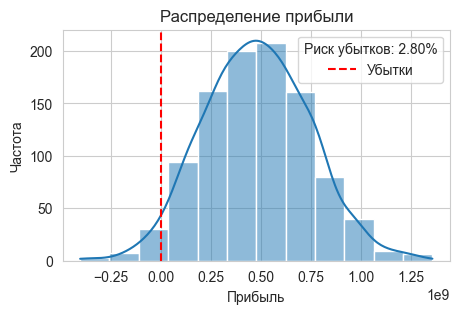

In [39]:
histogram(geo_data_0_2_results)

В сравнении с baseline мы смогли увеличить среднюю выручку на 70 млн. рублей и поднять нижнюю границу поднять интервала с 100 до 10 млн. убытков. Так результат риск убытков составляет 2.8% против 5.2%. Это существенное улучшение, но тем не менее не удовлетворяет условие задачи в 2.5%.

**Третий регион**

In [40]:
geo_data_2_results = SuperMegaBootStrap(y_geo2, preds2)

Средняя выручка для региона: 309 млн. рублей
95%-й доверительный интервал: (-228,936,011; 842,500,754) рублей
Риск убытков: 12.30%


In [41]:
geo_data_2_2_results = SuperMegaBootStrap(y_geo2_2, preds2_2)

Средняя выручка для региона: 563 млн. рублей
95%-й доверительный интервал: (31,981,616; 1,071,363,640) рублей
Риск убытков: 2.00%


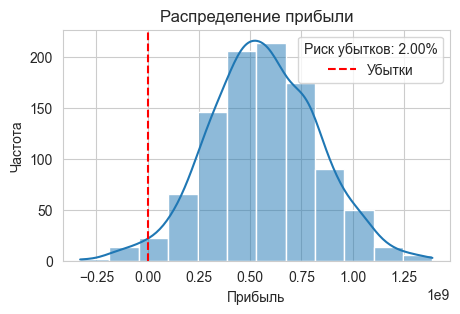

In [42]:
histogram(geo_data_2_2_results)

В третьем регионе нам удалось значительно снизить риск убытков с 12.3% до 2% в сравнении с изначальными данными. Даже с простой моделью выручка больше первого региона, это может указывать на то, что в данном регионе действительно больше запасов в скважинах, по этому риск убытков меньше, а средняя выручка существенно выше и составляет 563 млн. рублей.

Такой риск удовлетворяет условие задачи, по этому в качестве лучшего можем выбрать третий регион.

## Вывод <a id="end"></a>

**Цели исследования**: Исследовать данные о трёх регионах добычи нефти, обучить модели машинного обучения чтобы определить регион, где добыча принесёт наибольшую прибыль и проанализировать риски.

**Этапы работы:**

При обзоре данных были обнаруженны аномалии во втором регионе (geo_data_1), все значения объёма в скважинах были представлены 12 значениями на 100 тысяч строк данных, также объём имел идеальную линейную связь с f2, что является утечкой данных. Такие данные непригодны для обучения, модель покажет идеальный результат, но будет бесполезна на практике. В данных о первом и третьем регионе подобных ошибок нет;

Средний запас объёма нефти составляет 92.5 и 95 тысяч баррелей в первом и третьем регионе соответственно.

Изначально входные признаки показали слабую связь с целевым. В первом регионе удалось найти и разделить 2 группы значений в данных создав новый признак, по которому распределение объёма в группах отличается. Для третьего региона удалось выжать связь путём преобразования двух признаков, в результате их корреляция с объёмом увеличилась.

Благодаря новым признакам нам удалось улучшить качество обученых моделей и результаты тестов:
* В первом регионе средняя ошибка уменьшилась, что привело к снижению риска убытков с 5.2 до 2.8%, это также увеличило среднюю выручку на тесте на 70 млн. рублей и снизило нижнюю границу доверительного интервала в 10 раз. Итого средняя выручка для geo_data_0 составила 481 млн. рублей;
* В третьем регионе мы значительно снизили среднюю ошибку модели и уменьшили риск убытков на тесте с 12 до 2%, а средняя выручка увеличилась с 309 до 563 млн. рублей. Такое увеличение можно объяснить большим запасом нефти в данном регионе.
  
Качество моделей у первого и третьего региона примерно на одном уровне, учитывая разницу с тестах можно предложить, что в регионе geo_data_2 больше запасов в скважинах вследствие чего наименьший риск убытков.

**Рекомендация**

В данных geo_data_0 присутствуют нелинейные зависимости которые линейная регрессия не способна уловить, мы решили это добавив бинарный признак, но это не расскрывает полного потенциала данных, более сложные модели типа SVR или градиентного бустинга возможно показали бы лучшее качество на данных первого региона, что снизит риск и для этого региона. В контексте нашей задачи, конечно, для исследования рекомендуется регион geo_data_2, но существует потенциал и для первого региона.